# 4. Comparativo entre los cuatro sistemas 

Cierra el EDA poniendo **troncal, alimentadores, corredores y Metro L1** lado a lado.

**Precondición:** ya corriste los EDA por sistema (escriben en `data_processed/clean/`).

**Salidas de este notebook:**
- `calidad_cobertura.csv` — unión de los 4 CSV de cobertura
- `demanda_consolidada.parquet` — esquema común, **todas** las unidades
- `demanda_consolidada_fiable.parquet` — solo cobertura ≥ 90% (**usar este** para análisis)


## Setup — consolidar, marcar grano y filtrar cobertura ≥ 90%

El grano **no es el mismo** en todos los sistemas:
- **troncal / metro_l1:** `unidad` = estación
- **corredor / alimentador:** el Excel viene a nivel **paradero**, pero la unidad de
  cobertura/modelo que usamos es la **ruta** (sumamos paraderos de la misma ruta)


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)

_cwd = Path.cwd().resolve()
if (_cwd / "eda_comparativo_sistemas.ipynb").exists() or _cwd.name == "eda":
    RAIZ = _cwd.parents[1]
elif (_cwd / "data_processed").exists():
    RAIZ = _cwd
else:
    RAIZ = _cwd.parents[1]

CLEAN = RAIZ / "data_processed" / "clean"
FIGS = RAIZ / "docs" / "images"
FIGS.mkdir(parents=True, exist_ok=True)

UMBRAL = 90
PALETA = {
    "troncal": "#1f4e79", "alimentador": "#c0504d",
    "corredor": "#4f81bd", "metro_l1": "#2e7d32",
}
ORDEN_SIS = ["troncal", "alimentador", "corredor", "metro_l1"]
# qué representa `unidad` en cada sistema
GRANO = {
    "troncal": "estacion",
    "metro_l1": "estacion",
    "corredor": "ruta",
    "alimentador": "ruta",
}

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "font.size": 10,
    "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False,
    "axes.spines.right": False, "figure.autolayout": True,
})


def guardar_fig(nombre: str) -> None:
    destino = FIGS / nombre
    plt.savefig(destino, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"  [figura] {destino.relative_to(RAIZ)}")


def titular(t: str) -> None:
    print(f"\n{'='*78}\n{t}\n{'='*78}")


def perfil_porcentual(df: pd.DataFrame, valor: str = "validaciones") -> pd.Series:
    p = df.groupby("hora", observed=True)[valor].mean()
    return (p / p.sum() * 100).round(2)


def share_franja(pct: pd.Series, a: int, b: int) -> float:
    m = (pct.index >= a) & (pct.index <= b)
    return float(pct[m].sum())


titular("Unión de calidad_cobertura por sistema")
parts_cal = []
for f in sorted(CLEAN.glob("calidad_cobertura_*.csv")):
    parts_cal.append(pd.read_csv(f))
    print(f"  + {f.name}: {len(parts_cal[-1])} unidades")
if not parts_cal:
    raise FileNotFoundError(f"No hay calidad_cobertura_*.csv en {CLEAN}")
calidad = pd.concat(parts_cal, ignore_index=True)
for col in ("unidad", "sistema"):
    calidad[col] = calidad[col].astype("string")
calidad["grano"] = calidad["sistema"].map(GRANO)
calidad.to_csv(CLEAN / "calidad_cobertura.csv", index=False)
print(f"calidad_cobertura.csv: {len(calidad)} unidades")
print(calidad.groupby(["sistema", "grano"], observed=True)
      .agg(n=("unidad", "count"),
           fiables=("pct_cobertura", lambda s: int((s >= UMBRAL).sum())))
      .to_string())

titular("Construir demanda_consolidada (+ versión fiable)")
troncal = pd.read_parquet(CLEAN / "troncal_hora.parquet")
alim = pd.read_parquet(CLEAN / "alimentador_hora.parquet")
corr = pd.read_parquet(CLEAN / "corredores_hora.parquet")
l1 = pd.read_parquet(CLEAN / "metro_l1_total_hora.parquet")

partes = []
for sistema, df, unidad_col, extra in [
    ("troncal", troncal, "estacion", {}),
    ("alimentador", alim, "ruta", {"ruta": "ruta", "sentido": "sentido_norm"}),
    ("corredor", corr, "ruta", {"ruta": "ruta", "sentido": "sentido_norm"}),
    ("metro_l1", l1, "estacion", {}),
]:
    cols = ["fecha", "anio", "mes", "dia_semana", "tipo_dia", "semana_iso",
            "feriado", "es_feriado", "hora", "validaciones", unidad_col]
    for v in extra.values():
        if v not in cols:
            cols.append(v)
    p = df[[c for c in cols if c in df.columns]].copy()
    p["sistema"] = sistema
    p["grano"] = GRANO[sistema]
    p["unidad"] = p[unidad_col].astype("string")
    if "ruta" not in p.columns:
        p["ruta"] = pd.Series([pd.NA] * len(p), dtype="string")
    else:
        p["ruta"] = p["ruta"].astype("string")
    if "sentido" not in p.columns and "sentido_norm" in p.columns:
        p["sentido"] = p["sentido_norm"].astype("string")
    elif "sentido" not in p.columns:
        p["sentido"] = pd.Series([pd.NA] * len(p), dtype="string")
    else:
        p["sentido"] = p["sentido"].astype("string")
    partes.append(p[["sistema", "grano", "unidad", "ruta", "sentido", "fecha", "anio", "mes",
                     "dia_semana", "tipo_dia", "semana_iso", "feriado", "es_feriado",
                     "hora", "validaciones"]])

cons_all = pd.concat(partes, ignore_index=True)
cons_all["validaciones"] = pd.to_numeric(cons_all["validaciones"], errors="coerce").fillna(0)
cons_all.to_parquet(CLEAN / "demanda_consolidada.parquet", index=False, compression="snappy")
print(f"demanda_consolidada.parquet (todas): {len(cons_all):,} filas")

fiables_df = calidad[calidad["pct_cobertura"] >= UMBRAL][["sistema", "unidad", "grano"]].copy()
fiables_df["unidad"] = fiables_df["unidad"].astype("string")
# si calidad no traía grano, ya lo mapeamos arriba
cons = cons_all.merge(
    fiables_df[["sistema", "unidad"]].assign(_ok=True),
    on=["sistema", "unidad"], how="inner",
)
cons.to_parquet(CLEAN / "demanda_consolidada_fiable.parquet",
                index=False, compression="snappy")
print(f"demanda_consolidada_fiable.parquet (>={UMBRAL}%): {len(cons):,} filas")
print("Unidades fiables por sistema:")
for sis, u in fiables_df.groupby("sistema")["unidad"].apply(set).items():
    n_tot = int((calidad["sistema"] == sis).sum())
    print(f"  {sis:<12} {len(u):>3}/{n_tot}  grano={GRANO[sis]}")



Unión de calidad_cobertura por sistema
  + calidad_cobertura_alimentador.csv: 27 unidades
  + calidad_cobertura_corredor.csv: 26 unidades
  + calidad_cobertura_metro_l1.csv: 26 unidades
  + calidad_cobertura_troncal.csv: 46 unidades
calidad_cobertura.csv: 125 unidades
                       n  fiables
sistema     grano                
alimentador ruta      27       23
corredor    ruta      26       12
metro_l1    estacion  26       26
troncal     estacion  46       45

Construir demanda_consolidada (+ versión fiable)
demanda_consolidada.parquet (todas): 13,494,204 filas
demanda_consolidada_fiable.parquet (>=90%): 12,344,676 filas
Unidades fiables por sistema:
  alimentador   23/27  grano=ruta
  corredor      12/26  grano=ruta
  metro_l1      26/26  grano=estacion
  troncal       45/46  grano=estacion


### Qué encontramos (setup)

Quedaron dos parquet: el completo y el **fiable**. Todo el análisis de abajo usa solo
`demanda_consolidada_fiable`. Ojo: en corredores solo entra una parte de las rutas
(cobertura ≥ 90%); en L1/troncal casi todas.


## 1. Escala de cada sistema

Comparamos totales **y** una métrica por unidad **dentro del mismo grano**
(estación vs estación; ruta vs ruta). Mezclar estación con ruta engaña.



Escala por sistema (panel fiable)
                grano  unidades  unidades_tot  validaciones  validaciones_dia  por_unidad_dia  share_%
sistema                                                                                               
troncal      estacion        45            46   127492997.0          349296.0          7762.0     29.6
alimentador      ruta        23            27    19875011.0           54602.0          2374.0      4.6
corredor         ruta        12            26    81806743.0          224128.0         18677.0     19.0
metro_l1     estacion        26            26   201512887.0          552090.0         21234.0     46.8


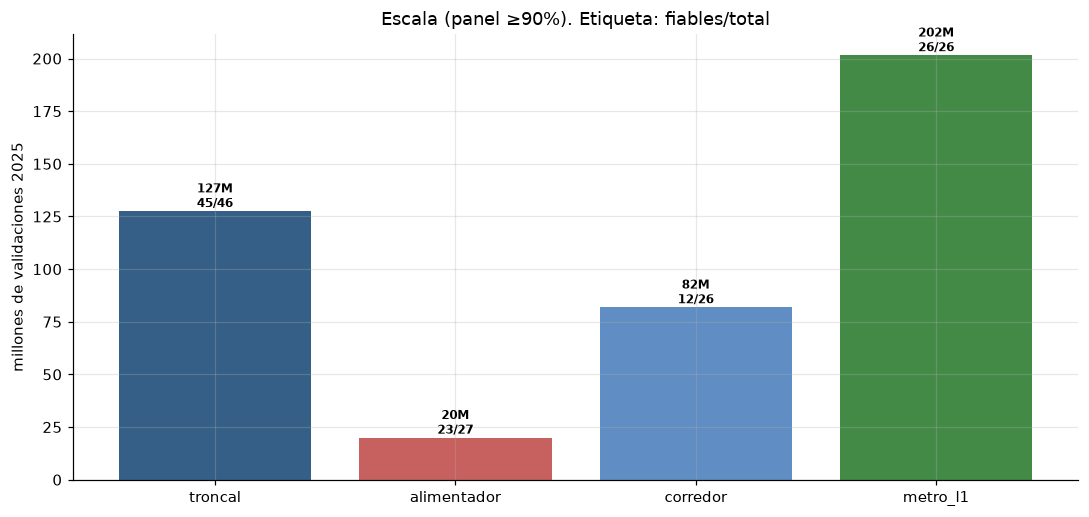

  [figura] docs/images/eda_comparativo_escala.png

Por unidad-día, separado por grano (no mezclar filas)

grano=estacion
          por_unidad_dia  unidades  unidades_tot  share_%
sistema                                                  
troncal           7762.0        45            46     29.6
metro_l1         21234.0        26            26     46.8

grano=ruta
             por_unidad_dia  unidades  unidades_tot  share_%
sistema                                                     
alimentador          2374.0        23            27      4.6
corredor            18677.0        12            26     19.0


In [2]:
titular("Escala por sistema (panel fiable)")
n_tot = calidad.groupby("sistema")["unidad"].nunique()
n_fia = fiables_df.groupby("sistema")["unidad"].nunique()

escala = (cons.groupby("sistema", observed=True)
          .agg(validaciones=("validaciones", "sum"),
               dias=("fecha", "nunique"),
               unidades=("unidad", "nunique"),
               horas=("hora", "nunique")))
escala["grano"] = escala.index.map(GRANO)
escala["unidades_tot"] = escala.index.map(n_tot)
escala["validaciones_dia"] = (escala["validaciones"] / escala["dias"]).round(0)
escala["por_unidad_dia"] = (escala["validaciones_dia"] / escala["unidades"]).round(0)
escala["share_%"] = (escala["validaciones"] / escala["validaciones"].sum() * 100).round(1)
escala = escala.reindex([s for s in ORDEN_SIS if s in escala.index])
print(escala[["grano", "unidades", "unidades_tot", "validaciones", "validaciones_dia",
              "por_unidad_dia", "share_%"]].to_string())

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(escala.index, escala["validaciones"] / 1e6,
       color=[PALETA[s] for s in escala.index], alpha=0.9)
for i, (s, v) in enumerate(escala["validaciones"].items()):
    ax.text(i, v / 1e6 + 2,
            f"{v/1e6:.0f}M\n{int(escala.loc[s,'unidades'])}/{int(escala.loc[s,'unidades_tot'])}",
            ha="center", fontsize=8, fontweight="bold")
ax.set_ylabel("millones de validaciones 2025")
ax.set_title("Escala (panel ≥90%). Etiqueta: fiables/total")
guardar_fig("eda_comparativo_escala.png")

# comparable within grain
titular("Por unidad-día, separado por grano (no mezclar filas)")
for grano, sistemas in [("estacion", ["troncal", "metro_l1"]),
                        ("ruta", ["alimentador", "corredor"])]:
    sub = escala.loc[[s for s in sistemas if s in escala.index],
                     ["por_unidad_dia", "unidades", "unidades_tot", "share_%"]]
    print(f"\ngrano={grano}")
    print(sub.to_string())


### Qué encontramos (escala)

La L1 concentra casi la mitad de las validaciones del panel fiable; los alimentadores
son el bloque más chico. `por_unidad_día` solo se interpreta **dentro del mismo grano**:
una estación de L1 no es comparable con una ruta de corredor.


## 2. Forma horaria: ¿son comparables los perfiles?

Normalizamos cada sistema a % de su propio día. Si las formas se parecen, un modelo
compartido (con dummies de sistema) es más defendible.



Perfil horario normalizado por sistema
Perfil horario (% del día):
      troncal  alimentador  corredor  metro_l1
hora                                          
0         0.0          0.2       0.0       0.0
1         0.0          0.0       0.0       0.0
2         0.0          0.0       0.0       0.0
3         0.0          0.0       0.0       0.0
4         0.3          0.0       0.2       0.0
5         3.0          3.5       3.3       2.4
6         8.2          9.2       7.5       5.9
7        10.4          9.6       8.8       7.6
8         7.9          6.7       7.0       7.2
9         5.0          4.5       5.1       5.8
10        4.1          3.8       4.6       4.9
11        3.8          3.4       4.4       4.5
12        4.1          3.7       4.9       4.7
13        4.7          4.0       5.4       5.3
14        4.4          3.8       5.0       5.2
15        4.5          3.6       5.4       5.3
16        5.4          4.2       6.3       5.9
17        8.8          6.4       7.7   

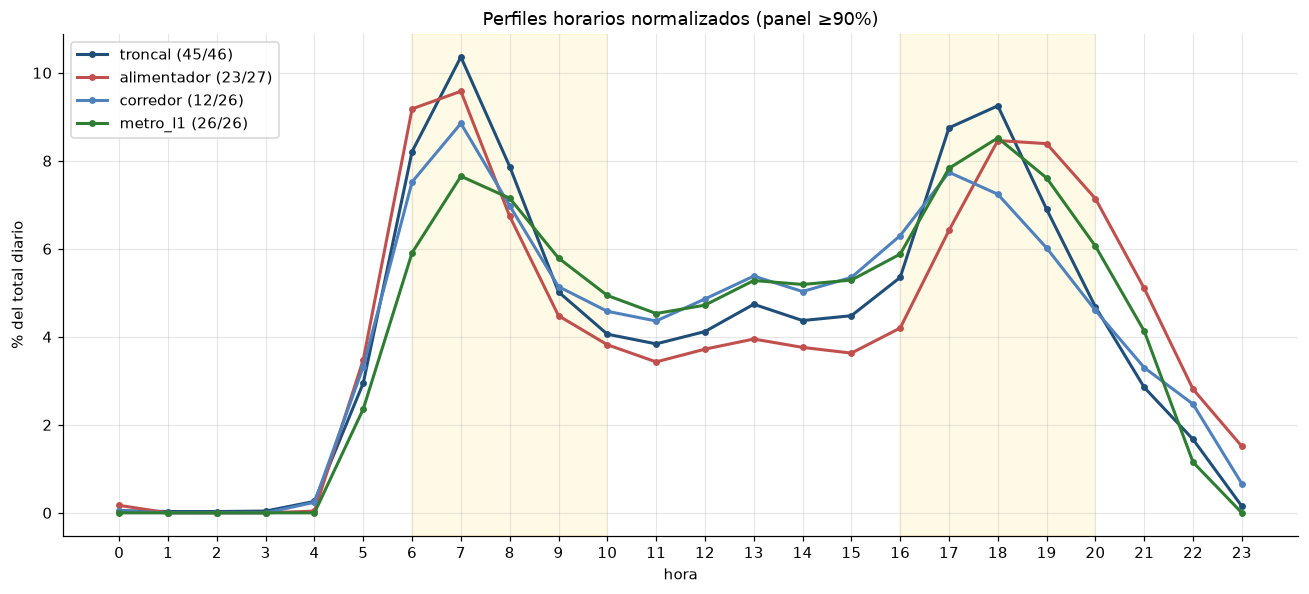

  [figura] docs/images/eda_comparativo_perfiles.png

Resumen (simetría = mañana/tarde; 1.00 = equilibrado):
             punta_manana_%  punta_tarde_%  hora_pico  simetria
troncal               35.52          34.93          7      1.02
alimentador           33.80          34.61          7      0.98
corredor              33.07          31.90          7      1.04
metro_l1              31.44          35.90         18      0.88


In [3]:
titular("Perfil horario normalizado por sistema")
perfiles = {}
for sis, sub in cons.groupby("sistema", observed=True):
    p = perfil_porcentual(sub).reindex(range(0, 24), fill_value=0.0)
    perfiles[sis] = p
perfil_completo = pd.DataFrame(perfiles)
perfil_completo = perfil_completo[[s for s in ORDEN_SIS if s in perfil_completo.columns]]

print("Perfil horario (% del día):")
print(perfil_completo.round(1).to_string())

fig, ax = plt.subplots(figsize=(12, 5.5))
for sis in perfil_completo.columns:
    n_f = int(n_fia.get(sis, 0)); n_t = int(n_tot.get(sis, 0))
    ax.plot(perfil_completo.index, perfil_completo[sis], marker="o", ms=3.5,
            color=PALETA.get(sis, "#777"), label=f"{sis} ({n_f}/{n_t})", lw=2)
ax.axvspan(6, 10, color="gold", alpha=0.10)
ax.axvspan(16, 20, color="gold", alpha=0.10)
ax.set_xticks(range(0, 24))
ax.set_xlabel("hora")
ax.set_ylabel("% del total diario")
ax.set_title("Perfiles horarios normalizados (panel ≥90%)")
ax.legend()
guardar_fig("eda_comparativo_perfiles.png")

resumen_perfil = pd.DataFrame({
    "punta_manana_%": {s: share_franja(p, 6, 10) for s, p in perfil_completo.items()},
    "punta_tarde_%": {s: share_franja(p, 16, 20) for s, p in perfil_completo.items()},
    "hora_pico": {s: int(p.idxmax()) for s, p in perfil_completo.items()},
    "simetria": {s: round(share_franja(p, 6, 10) / max(share_franja(p, 16, 20), 1e-9), 2)
                 for s, p in perfil_completo.items()},
})
resumen_perfil = resumen_perfil.reindex([s for s in ORDEN_SIS if s in resumen_perfil.index])
print("\nResumen (simetría = mañana/tarde; 1.00 = equilibrado):")
print(resumen_perfil.round(2).to_string())


### Qué encontramos (perfiles)

Los cuatro perfiles son de la misma familia (doble punta), pero la L1 abre ~5h y pica
al final de la tarde; los buses pican ~07h. La simetría mañana/tarde está cerca de 1
en buses; la L1 queda más cargada a la tarde.


## 3. Comportamiento ante el calendario

Miramos día de semana, feriados (promedio diario) y estacionalidad mensual.
La hipótesis: sábado ≠ domingo, y el Metro aguanta mejor el sábado laboral.



Respuesta ante el calendario — día de semana
Demanda relativa (LUN = 100):
dia_semana     LUN    MAR    MIÉ    JUE    VIE    SÁB   DOM
sistema                                                    
troncal      100.0  101.0   99.0   98.0  102.0   78.0  34.0
alimentador  100.0  103.0   99.0  101.0  102.0   77.0  39.0
corredor     100.0  100.0   97.0   96.0   99.0   75.0  37.0
metro_l1     100.0  101.0  100.0   98.0  102.0  101.0  55.0


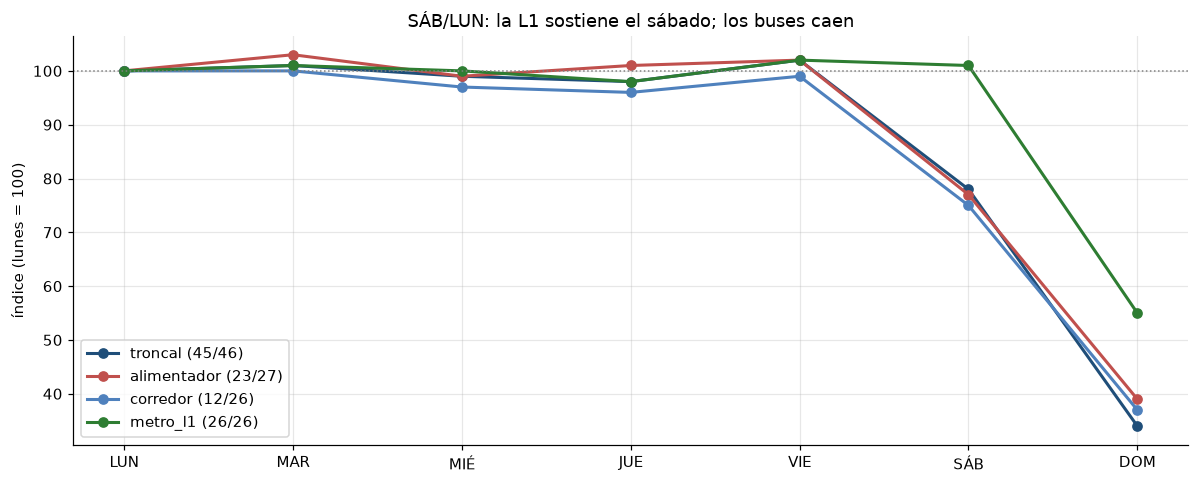

  [figura] docs/images/eda_comparativo_dia_semana.png

Ratios clave:
             SAB/LUN  DOM/LUN
sistema                      
troncal         0.78     0.34
alimentador     0.77     0.39
corredor        0.75     0.37
metro_l1        1.01     0.55


In [4]:
titular("Respuesta ante el calendario — día de semana")

pivot_dia = (cons.groupby(["sistema", "dia_semana"], observed=True)["validaciones"]
             .sum().unstack())
base = pivot_dia["LUN"]
rel = (pivot_dia.div(base, axis=0) * 100).round(0)
orden = ["LUN", "MAR", "MIÉ", "JUE", "VIE", "SÁB", "DOM"]
rel = rel[[c for c in orden if c in rel.columns]]
rel = rel.reindex([s for s in ORDEN_SIS if s in rel.index])
print("Demanda relativa (LUN = 100):")
print(rel.to_string())

fig, ax = plt.subplots(figsize=(11, 4.5))
for sis in rel.index:
    n_f = int(n_fia.get(sis, 0)); n_t = int(n_tot.get(sis, 0))
    ax.plot(rel.columns, rel.loc[sis], marker="o", color=PALETA.get(sis, "#777"),
            label=f"{sis} ({n_f}/{n_t})", lw=2)
ax.axhline(100, color="grey", ls=":", lw=1)
ax.set_ylabel("índice (lunes = 100)")
ax.set_title("SÁB/LUN: la L1 sostiene el sábado; los buses caen")
ax.legend()
guardar_fig("eda_comparativo_dia_semana.png")

tabla_fds = pd.DataFrame({
    "SAB/LUN": (rel["SÁB"] / 100).round(2),
    "DOM/LUN": (rel["DOM"] / 100).round(2),
})
print("\nRatios clave:")
print(tabla_fds.to_string())


### Qué encontramos (día de semana)

La L1 mantiene el sábado cerca del lunes; los tres sistemas de buses caen a ~0.75–0.78.
El domingo cae todo, pero menos en Metro. Agrupar “fin de semana” como un solo bloque
borra esa diferencia.



Feriados (promedio diario, no sumas)
Promedio diario feriado / laborable (%):
sistema
troncal        44.5
alimentador    45.5
corredor       43.3
metro_l1       61.4


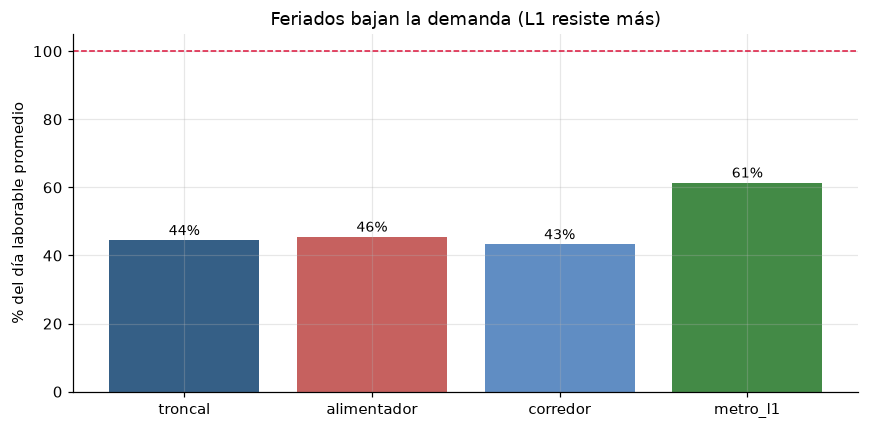

  [figura] docs/images/eda_comparativo_feriados.png


In [5]:
titular("Feriados (promedio diario, no sumas)")

diario = (cons.groupby(["sistema", "es_feriado", "fecha"], observed=True)["validaciones"]
          .sum().reset_index())
fer = (diario.groupby(["sistema", "es_feriado"], observed=True)["validaciones"]
       .mean().unstack(fill_value=0))
fer = fer.rename(columns={False: "laborable", True: "feriado"})
fer_rel = (fer["feriado"] / fer["laborable"] * 100).round(1)
fer_rel = fer_rel.reindex([s for s in ORDEN_SIS if s in fer_rel.index])
print("Promedio diario feriado / laborable (%):")
print(fer_rel.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(fer_rel.index, fer_rel.values,
       color=[PALETA.get(s, "#777") for s in fer_rel.index], alpha=0.9)
ax.axhline(100, color="crimson", ls="--", lw=1)
for i, s in enumerate(fer_rel.index):
    ax.text(i, fer_rel.loc[s] + 1.5, f"{fer_rel.loc[s]:.0f}%", ha="center", fontsize=9)
ax.set_ylabel("% del día laborable promedio")
ax.set_title("Feriados bajan la demanda (L1 resiste más)")
guardar_fig("eda_comparativo_feriados.png")


### Qué encontramos (feriados)

En promedio diario, un feriado deja la L1 ~60% de un laborable y a los buses ~43–46%.
Se usa promedio diario (no sumas) porque hay muchos menos feriados que laborables.



Estacionalidad: jul–ago y diciembre
    sistema  jul_ago_vs_resto_%  dic_vs_resto_%  cv_mensual_%
    troncal                -4.5             0.2           2.8
alimentador               -11.7           -35.3          15.6
   corredor                -6.6            -8.9           5.9
   metro_l1                -3.1             8.6           3.4


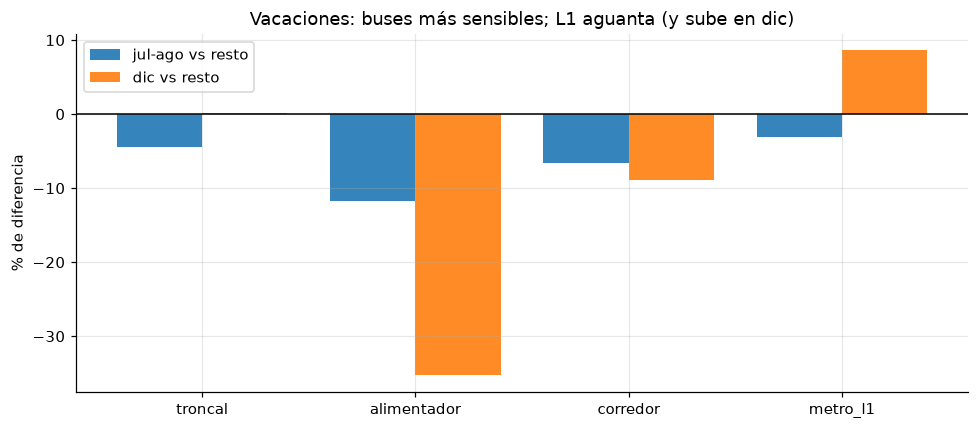

  [figura] docs/images/eda_comparativo_estacionalidad.png


In [6]:
titular("Estacionalidad: jul–ago y diciembre")
mensual = (cons.groupby(["sistema", "mes"], observed=True)["validaciones"].sum()
           / cons.groupby(["sistema", "mes"], observed=True)["fecha"].nunique())
tabla_est = []
for sis, serie in mensual.groupby(level=0):
    s = serie.droplevel(0)
    tabla_est.append({
        "sistema": sis,
        "jul_ago_vs_resto_%": round((s[[7, 8]].mean() / s.drop([7, 8]).mean() - 1) * 100, 1),
        "dic_vs_resto_%": round((s[12] / s.drop(12).mean() - 1) * 100, 1),
        "cv_mensual_%": round(s.std() / s.mean() * 100, 1),
    })
estacional = pd.DataFrame(tabla_est).set_index("sistema")
estacional = estacional.reindex([s for s in ORDEN_SIS if s in estacional.index]).reset_index()
print(estacional.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
e = estacional.set_index("sistema")
x = np.arange(len(e))
ax.bar(x - 0.2, e["jul_ago_vs_resto_%"], width=0.4, label="jul-ago vs resto", alpha=0.9)
ax.bar(x + 0.2, e["dic_vs_resto_%"], width=0.4, label="dic vs resto", alpha=0.9)
ax.set_xticks(x, e.index)
ax.axhline(0, color="black", lw=1)
ax.set_ylabel("% de diferencia")
ax.set_title("Vacaciones: buses más sensibles; L1 aguanta (y sube en dic)")
ax.legend()
guardar_fig("eda_comparativo_estacionalidad.png")


### Qué encontramos (estacionalidad)

Jul–ago y diciembre pegan más a alimentadores/corredores. La L1 apenas baja en
vacaciones escolares y **sube** en diciembre — perfil más laboral/comercial que escolar.


## 4. ¿Un modelo único o uno por unidad?

Medimos dispersión **dentro** de cada unidad y qué tan distintas son entre sí.
Interpretar rangos altos con cuidado: a veces es irregularidad real, a veces huecos
de cobertura (sobre todo alimentadores).


In [7]:
titular("Dispersión de la demanda diaria por unidad")
# agregamos a unidad-día (en rutas: suma de paraderos de esa ruta)
disper = (cons.groupby(["sistema", "grano", "unidad", "fecha"], observed=True)["validaciones"]
          .sum().groupby(level=[0, 1, 2]).agg(["mean", "std", "min", "max"]))
disper = disper.dropna(subset=["std"]).reset_index()
disper["cv"] = (disper["std"] / disper["mean"] * 100).round(1)
disper["rango"] = np.where(
    disper["min"] > 0,
    (disper["max"] / disper["min"]).round(1),
    np.nan,
)

resumen_disp = (disper.groupby(["sistema", "grano"], observed=True)
                .agg(unidades=("unidad", "nunique"),
                     cv_mediana=("cv", "median"),
                     rango_mediano=("rango", "median"),
                     rango_max=("rango", "max"))
                .round(1))
print(resumen_disp.to_string())
print("\n- cv_mediana alto → serie diaria irregular")
print("- rango_mediano muy alto en alimentadores → suele mezclar irregularidad + huecos")



Dispersión de la demanda diaria por unidad
                      unidades  cv_mediana  rango_mediano  rango_max
sistema     grano                                                   
alimentador ruta            23        44.4           40.0      505.8
corredor    ruta            12        28.0            5.8       18.3
metro_l1    estacion        26        20.8            6.4       19.1
troncal     estacion        45        30.0            5.4      861.2

- cv_mediana alto → serie diaria irregular
- rango_mediano muy alto en alimentadores → suele mezclar irregularidad + huecos


### Forma de la demanda diaria (violin, normalizado)

Cada unidad-día se expresa como proporción de la **media de esa unidad**, para
comparar formas entre sistemas sin mezclar escalas absolutas.


Violin — demanda diaria relativa a la media de cada unidad


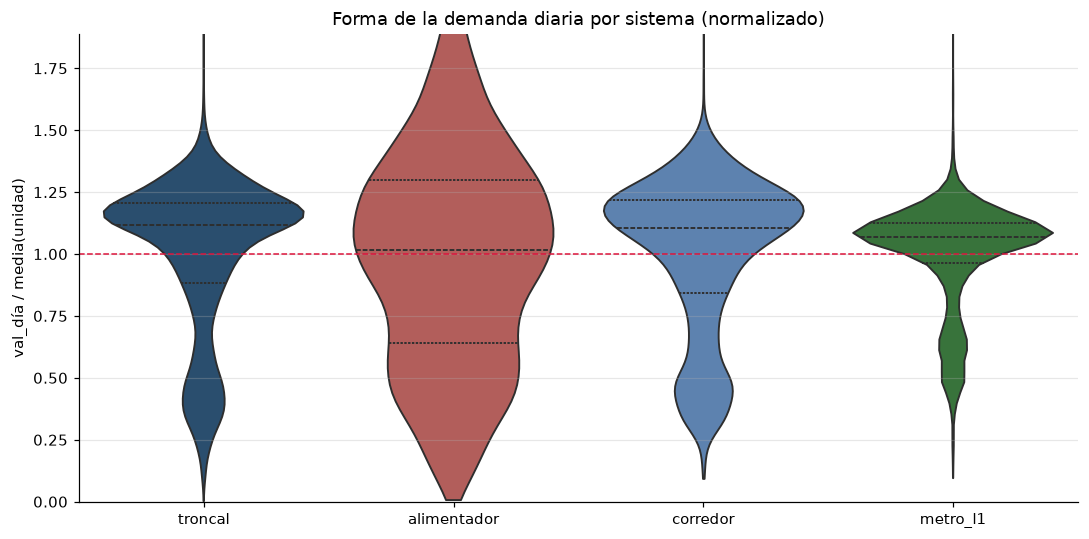

  [figura] docs/images/eda_comparativo_violin_diario.png
1.0 = día típico de la unidad; colas anchas → más irregularidad día a día


In [8]:
import seaborn as sns

titular("Violin — demanda diaria relativa a la media de cada unidad")
ud = (cons.groupby(["sistema", "unidad", "fecha"], observed=True)["validaciones"]
      .sum().reset_index())
ud["rel_media"] = ud["validaciones"] / ud.groupby(["sistema", "unidad"])["validaciones"].transform("mean")
ud = ud.replace([np.inf, -np.inf], np.nan).dropna(subset=["rel_media"])
ud = ud[ud["sistema"].isin(ORDEN_SIS)]

fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(
    data=ud, x="sistema", y="rel_media", hue="sistema", order=ORDEN_SIS,
    palette=PALETA, inner="quartile", cut=0, legend=False, ax=ax,
)
ax.axhline(1.0, color="crimson", ls="--", lw=1)
ax.set_ylabel("val_día / media(unidad)")
ax.set_xlabel("")
ax.set_title("Forma de la demanda diaria por sistema (normalizado)")
ax.set_ylim(0, ud["rel_media"].quantile(0.99) * 1.05)
guardar_fig("eda_comparativo_violin_diario.png")
print("1.0 = día típico de la unidad; colas anchas → más irregularidad día a día")

### Qué encontramos (violin)

Normalizando por la media de cada unidad, L1 y troncal se concentran cerca de 1.0;
alimentadores y corredores muestran colas más anchas (más días atípicos). Encaja con
el CV alto de alimentadores y justifica no tratar la volatilidad como igual en los
cuatro sistemas.

### Qué encontramos (dispersión)

Los alimentadores tienen el CV y el rango mediano más altos. Parte es demanda real
volátil; parte es cobertura incompleta aunque ya filtramos ≥90%.


In [9]:
titular("Separabilidad entre unidades (mismo grano)")
for sis in [s for s in ORDEN_SIS if s in disper["sistema"].unique()]:
    sub = disper[disper["sistema"] == sis]
    grano = GRANO[sis]
    print(f"\n{sis} (grano={grano}): {len(sub)} unidades")
    top = sub.nlargest(5, "mean")[["unidad", "mean"]].copy()
    top["mean"] = top["mean"].round(0)
    print("  Top 5 por demanda media diaria:")
    print(top.to_string(index=False))
    ratio = sub["mean"].max() / max(sub["mean"].min(), 1e-9)
    print(f"  Rango medias: {sub['mean'].min():,.0f} – {sub['mean'].max():,.0f} ({ratio:.0f}x)")



Separabilidad entre unidades (mismo grano)

troncal (grano=estacion): 45 unidades
  Top 5 por demanda media diaria:
          unidad    mean
        Naranjal 58577.0
       Matellini 26929.0
Estacion Central 20431.0
         Angamos 17300.0
    Javier Prado 15375.0
  Rango medias: 36 – 58,577 (1619x)

alimentador (grano=ruta): 23 unidades
  Top 5 por demanda media diaria:
           unidad   mean
Villa El Salvador 7272.0
    Puente Piedra 4705.0
         Ensenada 4222.0
Antúnez de Mayolo 3943.0
           Alisos 3594.0
  Rango medias: 447 – 7,272 (16x)

corredor (grano=ruta): 12 unidades
  Top 5 por demanda media diaria:
unidad    mean
   201 55131.0
   301 28121.0
   204 27890.0
   206 25920.0
   209 21549.0
  Rango medias: 1,728 – 55,131 (32x)

metro_l1 (grano=estacion): 26 unidades
  Top 5 por demanda media diaria:
           unidad    mean
          Gamarra 54952.0
       La Cultura 47598.0
          Bayóvar 46985.0
      Miguel Grau 38353.0
Villa El Salvador 37121.0
  Rango media

### Qué encontramos (separabilidad)

Dentro de cada sistema las unidades se separan por órdenes de magnitud (sobre todo
en rutas). Eso anticipa que un modelo sin identidad de unidad se queda corto.


## 5. Qué variable explica la demanda (exploratorio)

Árbol de decisión **solo como sonda**, no como modelo final:
- muestra balanceada por sistema
- sin `tipo_dia` (redundante con `dia_semana`)
- comparamos R² con/sin identidad de unidad



Importancia de variables (árbol exploratorio)
Muestra: 160,000 | R² holdout = 0.733
Importancia agregada (%):
mes                  0.1
feriado              0.7
día semana           0.9
sistema             13.6
hora                33.0
identidad unidad    51.6


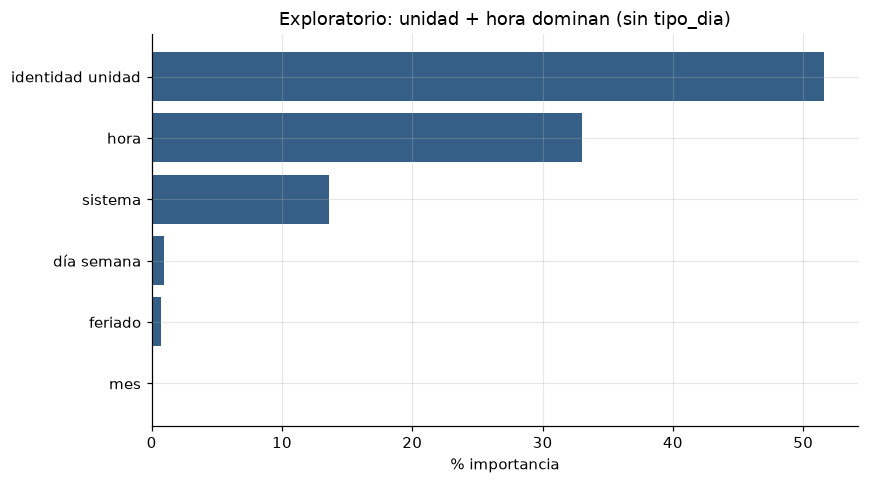

  [figura] docs/images/eda_comparativo_importancia.png


In [10]:
titular("Importancia de variables (árbol exploratorio)")
try:
    from sklearn.tree import DecisionTreeRegressor
    from sklearn.model_selection import train_test_split

    unit_hora = (cons.groupby(
        ["sistema", "grano", "unidad", "fecha", "hora", "dia_semana", "es_feriado", "mes"],
        observed=True,
    )["validaciones"].sum().reset_index())
    unit_hora = unit_hora[unit_hora["validaciones"] > 0].copy()
    unit_hora["hora"] = unit_hora["hora"].astype(int)
    unit_hora["es_feriado"] = unit_hora["es_feriado"].astype(int)
    unit_hora["unidad_id"] = pd.factorize(unit_hora["unidad"].astype(str) + "|" + unit_hora["sistema"])[0]

    parts = []
    for _, g in unit_hora.groupby("sistema", observed=True):
        parts.append(g.sample(n=min(40_000, len(g)), random_state=42))
    sample = pd.concat(parts, ignore_index=True)

    dummies = pd.get_dummies(sample[["sistema", "dia_semana"]], drop_first=True)
    X = pd.concat(
        [sample[["hora", "mes", "es_feriado", "unidad_id"]].reset_index(drop=True),
         dummies.reset_index(drop=True)],
        axis=1,
    )
    y = sample["validaciones"].to_numpy()
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
    arbol = DecisionTreeRegressor(max_depth=10, random_state=42)
    arbol.fit(Xtr, ytr)

    imp = pd.Series(arbol.feature_importances_, index=X.columns)
    buckets = {}
    for feat, val in imp.items():
        if feat == "unidad_id":
            key = "identidad unidad"
        elif feat in ("hora", "mes", "es_feriado"):
            key = {"hora": "hora", "mes": "mes", "es_feriado": "feriado"}[feat]
        elif str(feat).startswith("sistema_"):
            key = "sistema"
        elif str(feat).startswith("dia_semana_"):
            key = "día semana"
        else:
            key = str(feat)
        buckets[key] = buckets.get(key, 0.0) + float(val)
    imp_g = pd.Series(buckets).sort_values(ascending=True)

    print(f"Muestra: {len(sample):,} | R² holdout = {arbol.score(Xte, yte):.3f}")
    print("Importancia agregada (%):")
    print((imp_g * 100).round(1).to_string())

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.barh(imp_g.index, imp_g.values * 100, color="#1f4e79", alpha=0.9)
    ax.set_xlabel("% importancia")
    ax.set_title("Exploratorio: unidad + hora dominan (sin tipo_dia)")
    guardar_fig("eda_comparativo_importancia.png")
except ImportError:
    print("sklearn no disponible; se omite.")


### Qué encontramos (importancia)

En la sonda, **identidad de la unidad** y **hora** concentran casi toda la importancia.
Mes/feriado/día pesan poco. Es señal de diseño de features, no un ranking causal.


In [11]:
titular("¿Cuánto aporta la identidad de la unidad?")
try:
    from sklearn.tree import DecisionTreeRegressor
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import r2_score

    unit_hora = (cons.groupby(
        ["sistema", "unidad", "fecha", "hora", "dia_semana", "es_feriado", "mes"],
        observed=True,
    )["validaciones"].sum().reset_index())
    unit_hora = unit_hora[unit_hora["validaciones"] > 0].copy()
    unit_hora["hora"] = unit_hora["hora"].astype(int)
    unit_hora["unidad_id"] = pd.factorize(unit_hora["unidad"].astype(str) + "|" + unit_hora["sistema"])[0]

    parts = []
    for _, g in unit_hora.groupby("sistema", observed=True):
        parts.append(g.sample(n=min(50_000, len(g)), random_state=42))
    unit_hora = pd.concat(parts, ignore_index=True)

    dummies = pd.get_dummies(unit_hora[["sistema", "dia_semana"]], drop_first=True)
    calendario = pd.concat(
        [unit_hora[["hora", "mes"]].reset_index(drop=True), dummies.reset_index(drop=True)],
        axis=1,
    )
    calendario["es_feriado"] = unit_hora["es_feriado"].astype(int).to_numpy()
    con_unidad = calendario.copy()
    con_unidad["unidad_id"] = unit_hora["unidad_id"].to_numpy()
    y = unit_hora["validaciones"].to_numpy()

    print(f"Filas: {len(unit_hora):,} | unidades: {unit_hora['unidad_id'].nunique()}\n")
    r2s = {}
    for etiqueta, X in [("solo calendario (hora/día/mes/sistema)", calendario),
                        ("calendario + identidad de la unidad", con_unidad)]:
        Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
        arbol = DecisionTreeRegressor(max_depth=10, random_state=42)
        arbol.fit(Xtr, ytr)
        r2 = r2_score(yte, arbol.predict(Xte))
        r2s[etiqueta] = r2
        print(f"  {etiqueta:<42} R² = {r2:.3f}")
    print(f"\nΔ R² al añadir unidad ≈ {r2s['calendario + identidad de la unidad'] - r2s['solo calendario (hora/día/mes/sistema)']:.3f}")
except ImportError:
    print("sklearn no disponible; se omite.")



¿Cuánto aporta la identidad de la unidad?
Filas: 200,000 | unidades: 106

  solo calendario (hora/día/mes/sistema)     R² = 0.292
  calendario + identidad de la unidad        R² = 0.747

Δ R² al añadir unidad ≈ 0.455


### Qué encontramos (R² con/sin unidad)

El salto de R² al añadir la identidad de la unidad es grande. Un modelo solo con
calendario no alcanza; hace falta `unidad`/`ruta`/`estación` (o un efecto aleatorio).
Split aleatorio: es **exploratorio**, no validación temporal de producción.


## 6. Conclusiones comparativas

1. **Usar el parquet fiable** (`demanda_consolidada_fiable.parquet`) para análisis;
   el completo queda como inventario.
2. **Grano explícito:** no comparar `por_unidad_día` estación vs ruta.
3. **Escala:** L1 lidera el panel; corredores se interpretan con sus fiables/total.
4. **Calendario:** sábado ≠ domingo; L1 sostiene sábado; buses caen.
5. **Feriados/vacaciones** golpean más a buses; L1 más estable (y fuerte en dic).
6. **Modelado:** la identidad de la unidad aporta más que el calendario solo.
7. **Alimentadores** = más irregulares (demanda + cobertura).

Figuras: `docs/images/eda_comparativo_*.png`.
